In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy as pt 

# Linear Regression

In [2]:
hospital = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/hospital.csv")

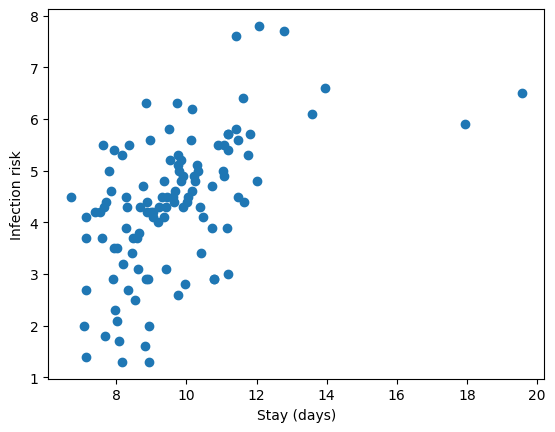

In [3]:
plt.scatter(hospital["stay"], hospital["infection_risk"])
plt.xlabel("Stay (days)")
plt.ylabel("Infection risk");

In [4]:
fit = smf.ols("infection_risk ~ nurses * stay", data = hospital).fit()
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         infection_risk   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     19.48
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           3.48e-10
Time:                        22:24:29   Log-Likelihood:                -168.73
No. Observations:                 113   AIC:                             345.5
Df Residuals:                     109   BIC:                             356.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.3488      0.989     -0.353      0.725      -2.308       1.611
nurses          0.0089      0.004      1.993      0.049    5.08e-05       0.018
stay            0.4498      0.106      4.253      0.000       0.240       0.659
nurses:stay    -0.0007      0.000     -1.499      0.137      -0.002       0.000
==============================================================================
Omnibus:                        0.593   Durbin-Watson:                   1.878
Prob(Omnibus):                  0.744   Jarque-Bera (JB):                0.716
Skew:                           0.153   Prob(JB):                        0.699
Kurtosis:                       2.758   Cond. No.                     2.27e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.27e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [5]:
ndf = pd.DataFrame.from_dict({"stay": [20, 20], "nurses": [100, 101]})
np.diff(fit.predict(ndf))

array([-0.00447639])

For each extra nurse, when stay is equal to 20, we expect infection risk to **decrease** by 0.004.

In [6]:
ndf = pd.DataFrame.from_dict({"stay": [10, 10], "nurses": [100, 101]})
np.diff(fit.predict(ndf))

array([0.00221305])

For each extra nurse, when stay is equal to 10, we expect infection risk to **increase** by 0.002.

# Logistic Regression

In [7]:
# change hospital -> possum
possum = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/possum.csv")

In [8]:
possum["vic"] = (possum["pop"].astype("string") == "vic").astype(np.float64)

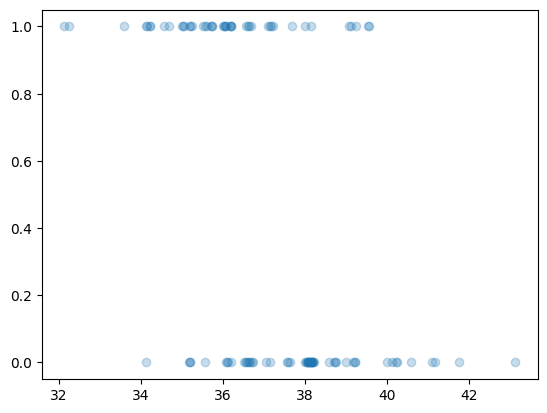

In [9]:
rng = np.random.default_rng()
N = np.shape(possum)[0]
plt.scatter(possum["tailL"] + rng.uniform(size = N) * 0.25, possum["vic"], 
            alpha = 0.25);

In [10]:
fit = smf.glm("vic ~ age * tailL", data = possum, 
              family = sm.families.Binomial()).fit()

In [11]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    vic   No. Observations:                  102
Model:                            GLM   Df Residuals:                       98
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -53.011
Date:                Tue, 02 Dec 2025   Deviance:                       106.02
Time:                        22:24:29   Pearson chi2:                     113.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2796
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.3407     15.472      3.189      0.001      19.016      79.665
age           -5.5348      3.032     -1.825      0.068     -11.478       0.409
tailL         -1.3680      0.422     -3.239      0.001      -2.196      -0.540
age:tailL      0.1554      0.082      1.887      0.059      -0.006       0.317
==============================================================================
"""

In [12]:
x = np.linspace(32, 44, 101)
m = np.mean(possum["age"])
ndf = pd.DataFrame.from_dict({"tailL": x, "age": np.full(101, m)})
yhat = fit.predict(ndf)

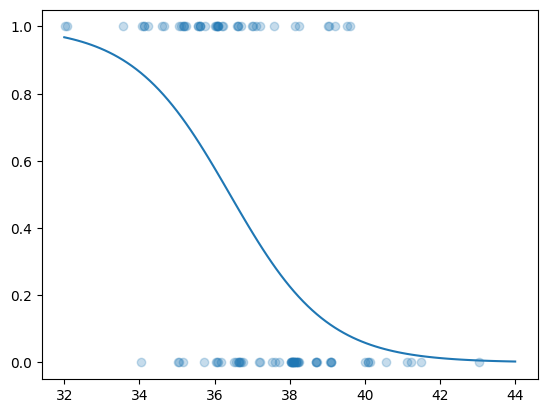

In [13]:
plt.scatter(possum["tailL"] + rng.uniform(size = N) * 0.25, possum["vic"], 
            alpha = 0.25);
plt.plot(x, yhat);

In [14]:
ndf = pd.DataFrame.from_dict({"tailL": [37, 38], "age": [m, m]})
np.diff(fit.predict(ndf))

array([-0.16145695])